# Fusion des données pour la création de data set

## Imports & variables

In [2]:
import pandas as pd
from scipy.spatial import cKDTree
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os


fichier_meteo = "../data/extraction/meteo.csv"
fichier_etp = "../data/extraction/etp.csv"
dossier_nappe = "../data/extraction/nappes/"

output_folder = "../data/fusion"

## Chargement des données météos

In [37]:
meteo = pd.read_csv(fichier_meteo, sep=";")

meteo = meteo[["AAAAMM", "RR", "TMM", "ETP","LAT","LON"]]
meteo = meteo.rename(columns={
    "AAAAMM": "time",
    "RR": "PRELIQ_Q",
    "TMM": "T_Q",
    "LAT": "lat",
    "LON": "lon"
})

meteo["time"] = pd.to_datetime(meteo["time"].astype(str), format="%Y%m")

meteo_month = meteo.sort_values("time").reset_index(drop=True)
# print(meteo_month.head())

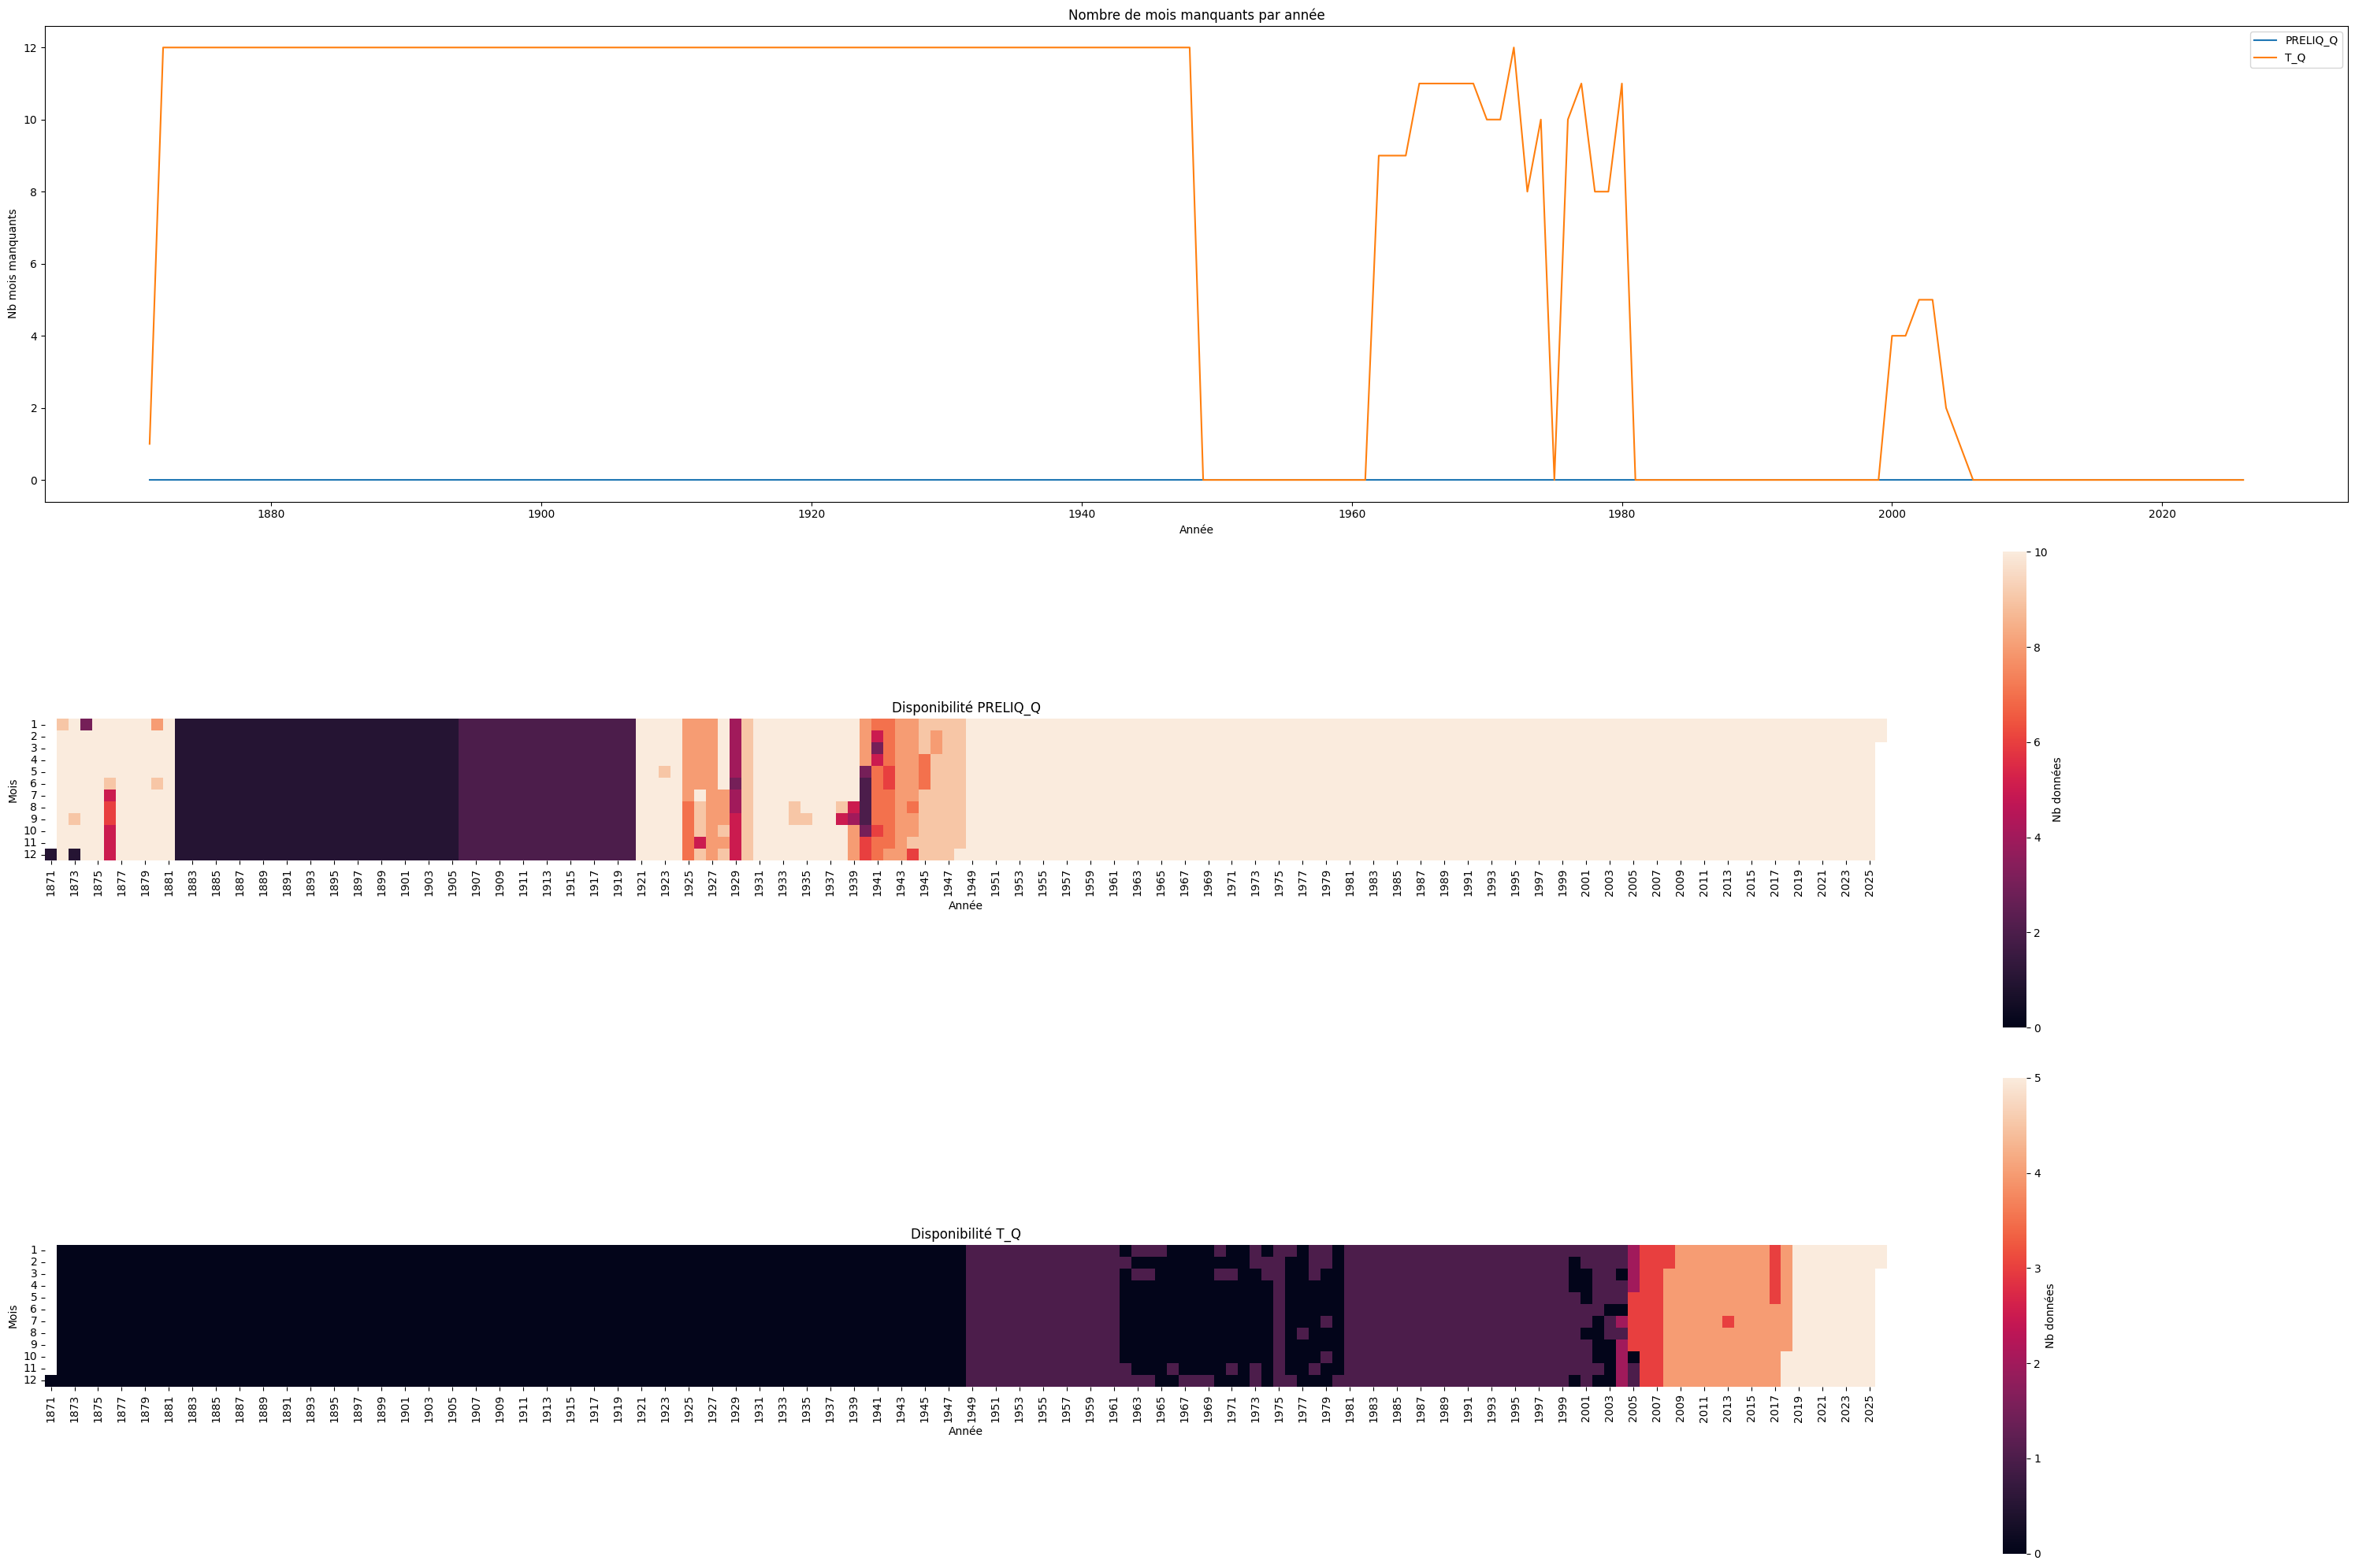

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(30, 20))

full_time = pd.date_range(
    start=meteo_month["time"].min(),
    end=meteo_month["time"].max(),
    freq="MS"
)

chrono = (
    meteo_month
    .groupby("time")[["PRELIQ_Q", "T_Q"]]
    .count()
    .reset_index()
)

chrono_full = pd.DataFrame({"time": full_time})
chrono_full = chrono_full.merge(chrono, on="time", how="left")
chrono_full[["PRELIQ_Q", "T_Q"]] = chrono_full[["PRELIQ_Q", "T_Q"]].fillna(0)

chrono_full["year"] = chrono_full["time"].dt.year
chrono_full["month"] = chrono_full["time"].dt.month

missing_year = (
    chrono_full
    .assign(
        PRELIQ_missing = chrono_full["PRELIQ_Q"] == 0,
        T_missing = chrono_full["T_Q"] == 0
    )
    .groupby("year")[["PRELIQ_missing", "T_missing"]]
    .sum()
    .reset_index()
)

axes[0].plot(missing_year["year"], missing_year["PRELIQ_missing"], label="PRELIQ_Q")
axes[0].plot(missing_year["year"], missing_year["T_missing"], label="T_Q")

axes[0].set_title("Nombre de mois manquants par année")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nb mois manquants")
axes[0].legend()

heatmap_meteo = chrono_full.pivot(
    index="month",
    columns="year",
    values="PRELIQ_Q"
)

heatmap_temp = chrono_full.pivot(
    index="month",
    columns="year",
    values="T_Q"
)

sns.heatmap(
    heatmap_meteo,
    ax=axes[1],
    vmin=0,
    vmax=10,
    square=True,
    cbar_kws={"label": "Nb données"}
)
axes[1].set_title("Disponibilité PRELIQ_Q")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Mois")

sns.heatmap(
    heatmap_temp,
    ax=axes[2],
    vmin=0,
    vmax=5,
    square=True,
    cbar_kws={"label": "Nb données"}
)
axes[2].set_title("Disponibilité T_Q")
axes[2].set_xlabel("Année")
axes[2].set_ylabel("Mois")

plt.tight_layout()
plt.show()



## Chargement des données d'évapotranspiration

In [36]:
etp = pd.read_csv(fichier_etp, sep=";")

# Conversion date (format 19700101)
etp["time"] = pd.to_datetime(etp["DATE"].astype(str), format="%Y%m%d")

etp = etp.rename(columns={
    "lat_dg": "lat",
    "lon_dg": "lon"
})

# Passage en mois
etp["month"] = etp["time"].dt.to_period("M")

# Agrégation mensuelle par maille (lat/lon)
etp_month = etp.groupby(["lat", "lon", "month"]).agg({
    "ETP_Q_H0175": "sum"   # ETP mensuelle = somme des jours
}).reset_index()

# Revenir en datetime
etp_month["time"] = etp_month["month"].dt.to_timestamp()

# Nettoyage
etp_month = etp_month.drop(columns=["month"])

# print(etp_month.head())


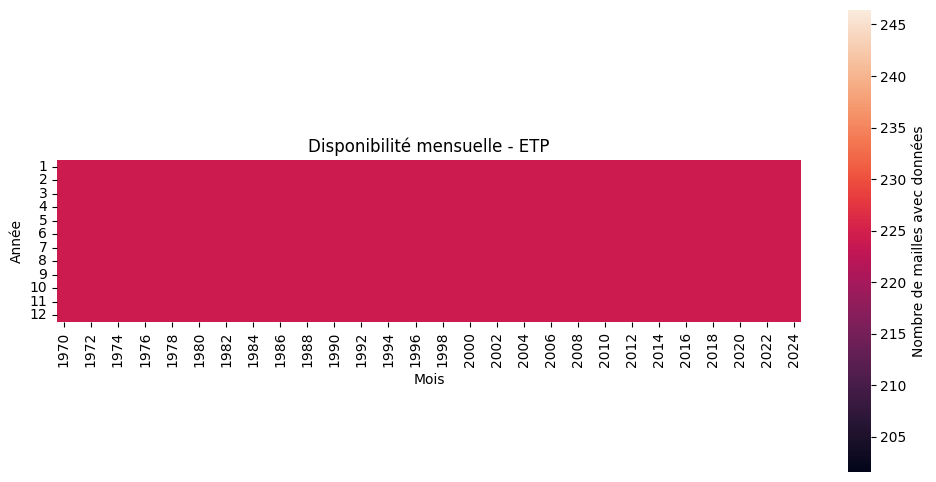

In [51]:
plt.figure(figsize=(12, 6))
chrono_etp = (
    etp_month
    .groupby("time")["ETP_Q_H0175"]
    .count()
    .reset_index(name="nb_points")
)

full_time = pd.date_range(
    start=etp_month["time"].min(),
    end=etp_month["time"].max(),
    freq="MS"   # début de mois
)

chrono_full_etp = pd.DataFrame({"time": full_time})

chrono_full_etp = chrono_full_etp.merge(
    chrono_etp,
    on="time",
    how="left"
)

# Mois totalement absents → 0
chrono_full_etp["nb_points"] = chrono_full_etp["nb_points"].fillna(0)

chrono_full_etp["year"] = chrono_full_etp["time"].dt.year

missing_etp_year = (
    chrono_full_etp
    .assign(missing = chrono_full_etp["nb_points"] == 0)
    .groupby("year")["missing"]
    .sum()
    .reset_index()
)

chrono_full_etp["year"] = chrono_full_etp["time"].dt.year
chrono_full_etp["month"] = chrono_full_etp["time"].dt.month

heatmap_etp = chrono_full_etp.pivot(
    columns="year",
    index="month",
    values="nb_points"
)


sns.heatmap(
    heatmap_etp,
    square=True,
    cbar_kws={"label": "Nombre de mailles avec données"}
)

plt.title("Disponibilité mensuelle - ETP")
plt.xlabel("Mois")
plt.ylabel("Année")
plt.show()


## Fusion

In [ ]:
os.makedirs(output_folder, exist_ok=True)

def nearest_point_valid(df_points, df_target, value_column):
    """
    Trouve pour chaque point cible le point le plus proche
    parmi ceux qui ont une valeur valide dans value_column.
    """
    # Garder seulement les points avec données
    df_valid = df_points.dropna(subset=[value_column])
    
    # S'il n'y a aucune donnée disponible
    if len(df_valid) == 0:
        return None, None
    
    tree = cKDTree(df_valid[["lat", "lon"]].values)
    _, idx = tree.query(df_target[["lat", "lon"]].values)
    
    return df_valid, idx


# Boucle sur tous les fichiers CSV de nappes
for fichier in os.listdir(dossier_nappe):
    if not fichier.endswith(".csv"):
        continue
    
    print("Traitement :", fichier)
    nappe = pd.read_csv(os.path.join(dossier_nappe, fichier), sep=";")
    
    # Préparer les données de nappe
    nappe = nappe.rename(columns={"date_mesure": "time"})
    nappe["time"] = pd.to_datetime(nappe["time"])
    nappe["month"] = nappe["time"].dt.to_period("M")
    
    nappe_month = nappe.groupby(["code_bss", "month"]).agg({
        "niveau_nappe_eau": "mean",
        "lon": "first",
        "lat": "first"
    }).reset_index()
    
    nappe_month["time"] = nappe_month["month"].dt.to_timestamp()
    nappe_month = nappe_month.drop(columns="month")
    
    # Initialiser colonnes ETP et météo
    nappe_month["ETP_Q_H0175"] = np.nan
    nappe_month["PRELIQ_Q"] = np.nan
    nappe_month["T_Q"] = np.nan
    
    # Fusion pour chaque date
    dates = nappe_month["time"].unique()
    for d in dates:
        mask = nappe_month["time"] == d
        df_day = nappe_month[mask]
        
        etp_day = etp_month[etp_month["time"] == d]
        meteo_day = meteo_month[meteo_month["time"] == d]

        if len(meteo_day) == 0:
            print("Pas de météo pour :", d)
        
        # Fusion ETP
        if len(etp_day) > 0:
            df_valid, idx_etp = nearest_point_valid(etp_day, df_day, "ETP_Q_H0175")
            if df_valid is not None:
                nappe_month.loc[mask, "ETP_Q_H0175"] = df_valid.iloc[idx_etp]["ETP_Q_H0175"].values
        
        # Fusion Météo
        if len(meteo_day) > 0:
            df_valid, idx_met = nearest_point_valid(meteo_day, df_day, "PRELIQ_Q")
            if df_valid is not None:
                nappe_month.loc[mask, "PRELIQ_Q"] = df_valid.iloc[idx_met]["PRELIQ_Q"].values
            df_valid, idx_met = nearest_point_valid(meteo_day, df_day, "T_Q")
            if df_valid is not None:
                nappe_month.loc[mask, "T_Q"] = df_valid.iloc[idx_met]["T_Q"].values
    
    # Déterminer le nom de sortie (code BSS du fichier)
    nom_nappe = nappe_month["code_bss"].iloc[0].replace("/", "_")   # supposé unique par fichier
    output_file = f"data_{nom_nappe}.csv"
    
    # Sauvegarde
    nappe_month.to_csv(os.path.join(output_folder, output_file), sep=";", index=False)


## Visualisation

Analyse des fichiers...
Shape : (28, 8)


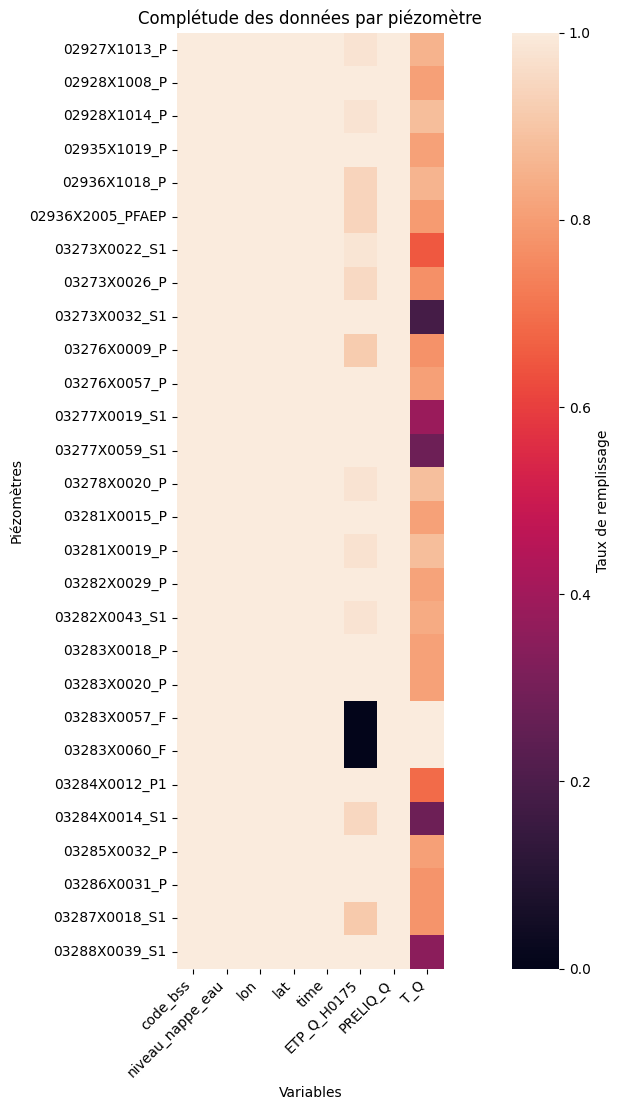

In [12]:
# Dossier contenant tes fichiers
folder = output_folder

results = []

print("Analyse des fichiers...")

for file in os.listdir(folder):
    if not file.endswith(".csv"):
        continue
    
    path = os.path.join(folder, file)
    df = pd.read_csv(path, sep=";")
    
    if len(df) == 0:
        continue
    
    total_rows = len(df)
    
    # Taux de remplissage par colonne
    fill_ratio = df.notna().sum() / total_rows
    
    fill_ratio["file"] = file.replace("data_", "").replace(".csv", "")
    results.append(fill_ratio)

# Construire la matrice
heat_df = pd.DataFrame(results)
heat_df = heat_df.set_index("file")
heat_df = heat_df.sort_index()

print("Shape :", heat_df.shape)

plt.figure(figsize=(14, max(6, len(heat_df) * 0.4)))

sns.heatmap(
    heat_df,
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Taux de remplissage"}
)

plt.title("Complétude des données par piézomètre")
plt.xlabel("Variables")
plt.ylabel("Piézomètres")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()
